In [1]:
%pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.3 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.3 MB 1.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.3 MB 2.0 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.1 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.3 MB 2.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.3 MB/s eta 0:00:02
   ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install --upgrade imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

  Attempting uninstall: sklearn-compat

    Found existing installation: sklearn-compat 0.1.5

    Uninstalling sklearn-compat-0.1.5:

      Successfully uninstalled sklearn-compat-0.1.5

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
  Attempting uninstall: imbalanced-learn
   ---------------------------------------- 0/2 [sklearn-compat]
    Found existing installation: imbalanced-learn 0.14.1
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
    Uninstalling imbalanced-learn-0.14.1:
   -------------------- ------------------- 1/2 [imbalanced-learn]
      Successfully uninstalled imbalanced-learn-0.14.1
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline




In [4]:
df=pd.read_csv('career_path_in_all_field.csv')

In [5]:
df.head(10)

,Field,Career,GPA,Extracurricular_Activities,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Coding_Skills,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,Industry_Certifications
0,Engineering,Urban Planner,3.530439,5,0,2,0,3,1,4,4,2,2,1,0,1,1
1,Chemistry,Art Director,4.018247,1,2,0,0,8,1,3,4,0,3,0,3,0,1
2,Engineering,Chemist,4.636733,1,0,0,0,5,0,1,1,1,2,2,3,4,1
3,Physics,Manager,4.052693,3,1,3,0,1,0,4,1,3,1,2,1,2,0
4,Law,Education Administrator,4.834850,0,2,4,0,0,0,4,4,3,4,4,3,2,0
5,Marketing,Accountant,4.029892,2,0,0,1,2,0,0,2,4,3,1,2,4,1
6,Medicine,Cybersecurity Analyst,3.226645,4,0,1,1,0,1,1,2,4,2,2,3,0,0
7,Computer Science,Special Education Teacher,4.378899,2,1,0,0,0,0,2,3,3,4,4,2,4,0
8,Education,Civil Engineer,3.671214,3,2,0,1,3,0,0,0,1,0,2,3,3,1
9,Medicine,Artist,3.905220,5,2,2,1,7,0,2,4,4,4,0,3,2,1


In [6]:
df.shape

(9000, 17)

In [7]:
data=df.copy()

In [8]:
numerical_features = [features for features in data.columns if data[features].dtypes!='O']

print("Number of numerical variables: ",len(numerical_features))

#visualize the numerical variables
data[numerical_features].head()

Number of numerical variables:  17


,Field,Career,GPA,Extracurricular_Activities,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Coding_Skills,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,Industry_Certifications
0,Engineering,Urban Planner,3.530439,5,0,2,0,3,1,4,4,2,2,1,0,1,1
1,Chemistry,Art Director,4.018247,1,2,0,0,8,1,3,4,0,3,0,3,0,1
2,Engineering,Chemist,4.636733,1,0,0,0,5,0,1,1,1,2,2,3,4,1
3,Physics,Manager,4.052693,3,1,3,0,1,0,4,1,3,1,2,1,2,0
4,Law,Education Administrator,4.834850,0,2,4,0,0,0,4,4,3,4,4,3,2,0


In [9]:
categorical_features = [features for features in data.columns if data[features].dtypes=='O']

print("Number of categorical variables: ",len(categorical_features))

#visualize the categorical variables
data[categorical_features].head()

Number of categorical variables:  0


""
0
1
2
3
4


In [10]:
for feature in categorical_features:
    print("The feature is {} and number of categories are {}".format(feature,len(data[feature].unique())))
    print(data[feature].unique())

In [11]:
for feature in numerical_features:
    print("The feature is {} and number of categories are {}".format(feature,len(data[feature].unique())))

The feature is Field and number of categories are 15
The feature is Career and number of categories are 90
The feature is GPA and number of categories are 9000
The feature is Extracurricular_Activities and number of categories are 10
The feature is Internships and number of categories are 3
The feature is Projects and number of categories are 5
The feature is Leadership_Positions and number of categories are 2
The feature is Field_Specific_Courses and number of categories are 10
The feature is Research_Experience and number of categories are 2
The feature is Coding_Skills and number of categories are 5
The feature is Communication_Skills and number of categories are 5
The feature is Problem_Solving_Skills and number of categories are 5
The feature is Teamwork_Skills and number of categories are 5
The feature is Analytical_Skills and number of categories are 5
The feature is Presentation_Skills and number of categories are 5
The feature is Networking_Skills and number of categories are 

In [12]:
##Handling missing values
data = data.dropna()

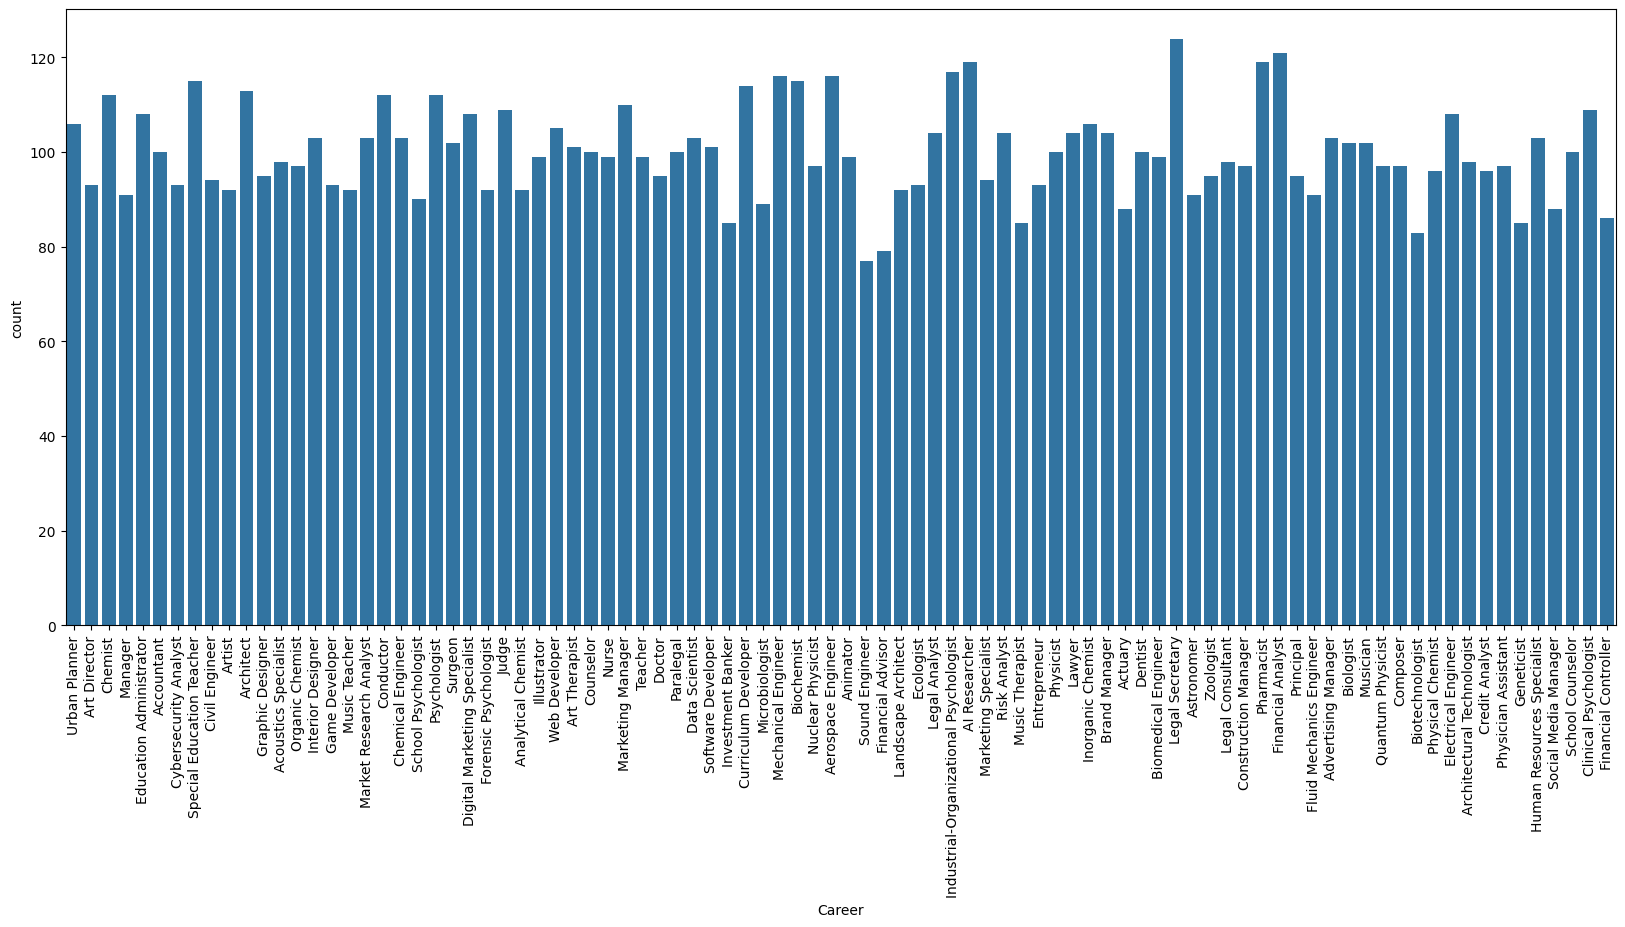

In [13]:
plt.figure(figsize=(20,8))
chart = sns.countplot(x=data['Career'])
chart.set_xticks(chart.get_xticks()) # Fixed tick positions
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.show()

In [14]:
print(data['Career'].value_counts())

Career
Legal Secretary                           124
Financial Analyst                         121
AI Researcher                             119
Pharmacist                                119
Industrial-Organizational Psychologist    117
                                         ... 
Music Therapist                            85
Geneticist                                 85
Biotechnologist                            83
Financial Advisor                          79
Sound Engineer                             77
Name: count, Length: 90, dtype: int64


In [15]:
'''def group_career(career_title):
    # Legal and Regulatory
    if career_title in ['Legal Secretary', 'Judge', 'Lawyer', 'Legal Analyst', 'Paralegal', 'Legal Consultant']:
        return "Legal and Regulatory"
    
    # Finance and Risk
    elif career_title in ['Financial Analyst', 'Risk Analyst', 'Accountant', 'Credit Analyst', 'Actuary', 'Financial Controller', 'Investment Banker', 'Financial Advisor']:
        return "Finance and Risk"
    
    # Healthcare and Medicine
    elif career_title in ['Pharmacist', 'Surgeon', 'Physician Assistant', 'Doctor', 'Dentist', 'Nurse','Psychologist', 'Clinical Psychologist']:
        return "Healthcare and Medicine"
    
    # Engineering (Physical)
    elif career_title in ['Mechanical Engineer', 'Aerospace Engineer', 'Electrical Engineer', 'Chemical Engineer', 'Biomedical Engineer', 'Civil Engineer', 'Fluid Mechanics Engineer', 'Sound Engineer', 'Architectural Technologist', 'Construction Manager']:
        return "Engineering (Physical)"
    
    # Physical and Life Sciences
    elif career_title in ['Physicist', 'Nuclear Physicist', 'Quantum Physicist', 'Chemist', 'Inorganic Chemist', 'Organic Chemist', 'Physical Chemist', 'Analytical Chemist', 'Biologist', 'Zoologist', 'Microbiologist', 'Geneticist', 'Astronomer', 'Ecologist']:
        return "Physical and Life Sciences"
    
    # Mental Health and Therapy
    #elif career_title in ['Psychologist', 'Clinical Psychologist', 'Counselor', 'School Counselor', 'School Psychologist', 'Art Therapist', 'Music Therapist']:
        #return "Mental Health and Therapy"
    
    # Education and Pedagogy
    elif career_title in ['Special Education Teacher', 'Teacher', 'Music Teacher', 'Curriculum Developer', 'Principal', 'Education Administrator','Counselor', 'School Counselor', 'School Psychologist']:
        return "Education and Pedagogy"
    
    # Tech and Data Science
    elif career_title in ['AI Researcher', 'Web Developer', 'Data Scientist', 'Software Developer', 'Cybersecurity Analyst', 'Game Developer']:
        return "Tech and Data Science"
    
    # Marketing and Strategy
    elif career_title in ['Marketing Manager', 'Marketing Specialist', 'Digital Marketing Specialist', 'Brand Manager', 'Market Research Analyst', 'Advertising Manager', 'Social Media Manager', 'Manager', 'Human Resources Specialist', 'Entrepreneur']:
        return "Marketing and Strategy"
    
    # Design and Architecture
    elif career_title in ['Architect', 'Interior Designer', 'Urban Planner', 'Landscape Architect', 'Animator', 'Graphic Designer']:
        return "Design and Architecture"
    
    # Creative Arts and Music
    elif career_title in ['Conductor', 'Musician', 'Composer', 'Artist', 'Illustrator',  'Art Director','Art Therapist', 'Music Therapist']:
        return "Creative Arts and Music"
    
    # Corporate Management
    #elif career_title in ['Manager', 'Human Resources Specialist', 'Entrepreneur']:
        #return "Corporate Management"
    
    # Specialized Applied Science
    elif career_title in ['Industrial-Organizational Psychologist', 'Biochemist', 'Biotechnologist', 'Forensic Psychologist', 'Acoustics Specialist']:
        return "Specialized Applied Science"
    
    else:
        return "Other/Unknown"
'''



'def group_career(career_title):\n    # Legal and Regulatory\n    if career_title in [\'Legal Secretary\', \'Judge\', \'Lawyer\', \'Legal Analyst\', \'Paralegal\', \'Legal Consultant\']:\n        return "Legal and Regulatory"\n\n    # Finance and Risk\n    elif career_title in [\'Financial Analyst\', \'Risk Analyst\', \'Accountant\', \'Credit Analyst\', \'Actuary\', \'Financial Controller\', \'Investment Banker\', \'Financial Advisor\']:\n        return "Finance and Risk"\n\n    # Healthcare and Medicine\n    elif career_title in [\'Pharmacist\', \'Surgeon\', \'Physician Assistant\', \'Doctor\', \'Dentist\', \'Nurse\',\'Psychologist\', \'Clinical Psychologist\']:\n        return "Healthcare and Medicine"\n\n    # Engineering (Physical)\n    elif career_title in [\'Mechanical Engineer\', \'Aerospace Engineer\', \'Electrical Engineer\', \'Chemical Engineer\', \'Biomedical Engineer\', \'Civil Engineer\', \'Fluid Mechanics Engineer\', \'Sound Engineer\', \'Architectural Technologist\', \'C

In [16]:
'''def group_career(career):
    career = str(career).lower()

    # 1. Technology
    if any(x in career for x in [
        'software', 'developer', 'programmer', 'data', 'ai', 'machine learning',
        'cyber', 'web', 'cloud'
    ]):
        return 'Technology'

    # 2. Engineering (separate from tech)
    elif any(x in career for x in [
        'engineer', 'mechanical', 'civil', 'electrical', 'electronics'
    ]):
        return 'Engineering'

    # 3. Healthcare
    elif any(x in career for x in [
        'doctor', 'nurse', 'medical', 'pharma', 'dentist'
    ]):
        return 'Healthcare'

    # 4. Business & Finance
    elif any(x in career for x in [
        'manager', 'business', 'account', 'finance', 'marketing', 'sales'
    ]):
        return 'Business'

    # 5. Education
    elif any(x in career for x in [
        'teacher', 'professor', 'lecturer', 'education'
    ]):
        return 'Education'

    # 6. Creative & Media
    elif any(x in career for x in [
        'design', 'artist', 'writer', 'music', 'media', 'animation'
    ]):
        return 'Creative'

    # 7. Government / Law
    elif any(x in career for x in [
        'government', 'upsc', 'ssc', 'civil service', 'police', 'law', 'judge'
    ]):
        return 'Government'

    # 8. Generic fallback → NOT Other
    else:
        return 'Business'
        '''
        

"def group_career(career):\n    career = str(career).lower()\n\n    # 1. Technology\n    if any(x in career for x in [\n        'software', 'developer', 'programmer', 'data', 'ai', 'machine learning',\n        'cyber', 'web', 'cloud'\n    ]):\n        return 'Technology'\n\n    # 2. Engineering (separate from tech)\n    elif any(x in career for x in [\n        'engineer', 'mechanical', 'civil', 'electrical', 'electronics'\n    ]):\n        return 'Engineering'\n\n    # 3. Healthcare\n    elif any(x in career for x in [\n        'doctor', 'nurse', 'medical', 'pharma', 'dentist'\n    ]):\n        return 'Healthcare'\n\n    # 4. Business & Finance\n    elif any(x in career for x in [\n        'manager', 'business', 'account', 'finance', 'marketing', 'sales'\n    ]):\n        return 'Business'\n\n    # 5. Education\n    elif any(x in career for x in [\n        'teacher', 'professor', 'lecturer', 'education'\n    ]):\n        return 'Education'\n\n    # 6. Creative & Media\n    elif any(x i

In [17]:
def group_career(career):
    career = str(career).lower()

    # 1. Tech (VERY SPECIFIC FIRST)
    if any(x in career for x in [
        'ai', 'machine learning', 'data scientist', 'software', 'web developer',
        'game developer', 'programmer'
    ]):
        return 'Tech'

    # 2. Cybersecurity
    elif 'cyber' in career:
        return 'Cybersecurity'

    # 3. Core Engineering
    elif any(x in career for x in [
        'mechanical', 'civil', 'electrical', 'aerospace', 'fluid'
    ]):
        return 'Engineering'

    # 4. Chemical / Biomedical Engg
    elif any(x in career for x in [
        'chemical engineer', 'biomedical engineer'
    ]):
        return 'Chemical/Biomedical Engg'

    # 5. Physical Sciences
    elif any(x in career for x in [
        'physicist', 'chemist'
    ]):
        return 'Physical Sciences'

    # 6. Life Sciences
    elif any(x in career for x in [
        'biologist', 'microbiologist', 'genetic', 'zoologist', 'ecologist', 'biotech'
    ]):
        return 'Life Sciences'

    # 7. Medical Doctor
    elif any(x in career for x in [
        'doctor', 'surgeon'
    ]):
        return 'Medical Doctor'

    # 8. Healthcare
    elif any(x in career for x in [
        'nurse', 'pharmacist', 'dentist', 'physician assistant'
    ]):
        return 'Healthcare'

    # 9. Psychology
    elif any(x in career for x in [
        'psychologist', 'counselor', 'therapist'
    ]):
        return 'Psychology'

    # 10. Law
    elif any(x in career for x in [
        'lawyer', 'judge', 'legal', 'paralegal'
    ]):
        return 'Law'

    # 11. Finance
    elif any(x in career for x in [
        'finance', 'investment', 'account', 'actuary', 'credit'
    ]):
        return 'Finance'

    # 12. Business
    elif any(x in career for x in [
        'manager', 'entrepreneur'
    ]):
        return 'Business'

    # 13. Marketing
    elif any(x in career for x in [
        'marketing', 'brand', 'advertising', 'social media'
    ]):
        return 'Marketing'

    # 14. HR
    elif any(x in career for x in [
        'human resources', 'organizational'
    ]):
        return 'HR'

    # 15. Education
    elif any(x in career for x in [
        'teacher', 'education', 'principal', 'curriculum'
    ]):
        return 'Education'

    # 16. Creative Arts
    elif any(x in career for x in [
        'artist', 'designer', 'illustrator', 'animator'
    ]):
        return 'Creative Arts'

    # 17. Music
    elif any(x in career for x in [
        'musician', 'composer', 'conductor', 'music', 'sound'
    ]):
        return 'Music'

    # 18. Architecture
    elif any(x in career for x in [
        'architect', 'interior', 'urban planner', 'landscape'
    ]):
        return 'Architecture'

    # 19. Construction
    elif 'construction' in career:
        return 'Construction'

    # 20. Analytics
    elif any(x in career for x in [
        'analyst', 'research'
    ]):
        return 'Analytics'

    # 21. Astronomy
    elif 'astronomer' in career:
        return 'Astronomy'

    # 22. Acoustics
    elif 'acoustic' in career:
        return 'Acoustics'

    # 23. Biochemistry
    elif 'biochemist' in career:
        return 'Biochemistry'

    # FINAL fallback (safe)
    else:
        return 'Other'
        

In [18]:
#data['Career_Grouped'] = data['Career'].map(career_mapping)

In [19]:
#data['Career_Grouped'] = data['Career'].fillna("Other")

In [20]:
data['Career_Grouped'] = data['Career'].apply(group_career)

In [21]:
data.head(10)

,Field,Career,GPA,Extracurricular_Activities,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Coding_Skills,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,Industry_Certifications,Career_Grouped
0,Engineering,Urban Planner,3.530439,5,0,2,0,3,1,4,4,2,2,1,0,1,1,Architecture
1,Chemistry,Art Director,4.018247,1,2,0,0,8,1,3,4,0,3,0,3,0,1,Other
2,Engineering,Chemist,4.636733,1,0,0,0,5,0,1,1,1,2,2,3,4,1,Physical Sciences
3,Physics,Manager,4.052693,3,1,3,0,1,0,4,1,3,1,2,1,2,0,Business
4,Law,Education Administrator,4.834850,0,2,4,0,0,0,4,4,3,4,4,3,2,0,Education
5,Marketing,Accountant,4.029892,2,0,0,1,2,0,0,2,4,3,1,2,4,1,Finance
6,Medicine,Cybersecurity Analyst,3.226645,4,0,1,1,0,1,1,2,4,2,2,3,0,0,Cybersecurity
7,Computer Science,Special Education Teacher,4.378899,2,1,0,0,0,0,2,3,3,4,4,2,4,0,Education
8,Education,Civil Engineer,3.671214,3,2,0,1,3,0,0,0,1,0,2,3,3,1,Engineering
9,Medicine,Artist,3.905220,5,2,2,1,7,0,2,4,4,4,0,3,2,1,Creative Arts


In [22]:
print(data['Career_Grouped'].value_counts())

Career_Grouped
Physical Sciences           912
Psychology                  906
Business                    686
Law                         639
Education                   623
Life Sciences               547
Engineering                 525
Tech                        521
Creative Arts               488
Healthcare                  415
Architecture                409
Music                       388
Finance                     369
Analytics                   328
Other                       258
Chemical/Biomedical Engg    202
Marketing                   202
Medical Doctor              197
HR                          103
Acoustics                    98
Cybersecurity                93
Astronomy                    91
Name: count, dtype: int64


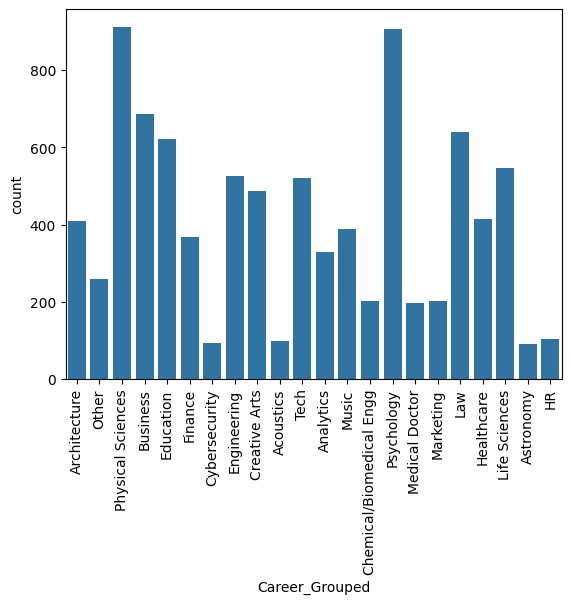

In [23]:
chart = sns.countplot(x=data['Career_Grouped'])
chart.set_xticks(chart.get_xticks()) # Fixed tick positions
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.show()

In [24]:
#data['GPA'] = data['GPA'].round(2)

In [25]:
##Split Features and Target
X = data.drop(columns=['Career','Career_Grouped'])   ##independent features
y = data['Career_Grouped']    ##dependent feature

In [26]:
X = pd.get_dummies(X, drop_first=True)

In [27]:
#print(data['Career_Grouped'].value_counts())

In [28]:
'''##Encode Categorical columns
from sklearn.preprocessing import LabelEncoder
X_encoder = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_encoder[col] = le

y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)
print(data.head())'''

"##Encode Categorical columns\nfrom sklearn.preprocessing import LabelEncoder\nX_encoder = {}\n\nfor col in X.select_dtypes(include='object').columns:\n    le = LabelEncoder()\n    X[col] = le.fit_transform(X[col])\n    X_encoder[col] = le\n\ny_encoder = LabelEncoder()\ny = y_encoder.fit_transform(y)\nprint(data.head())"

In [29]:
print(X.head())
print(y[:5])

        GPA  Extracurricular_Activities  Internships  Projects  \
0  3.530439                           5            0         2   
1  4.018247                           1            2         0   
2  4.636733                           1            0         0   
3  4.052693                           3            1         3   
4  4.834850                           0            2         4   

   Leadership_Positions  Field_Specific_Courses  Research_Experience  \
0                     0                       3                    1   
1                     0                       8                    1   
2                     0                       5                    0   
3                     0                       1                    0   
4                     0                       0                    0   

   Coding_Skills  Communication_Skills  Problem_Solving_Skills  ...  \
0              4                     4                       2  ...   
1              3            

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [32]:
y_train.value_counts()

Career_Grouped
Psychology                  722
Healthcare                  722
Physical Sciences           722
Engineering                 722
Business                    722
Architecture                722
Law                         722
Other                       722
Cybersecurity               722
Creative Arts               722
Tech                        722
Music                       722
Chemical/Biomedical Engg    722
Life Sciences               722
Medical Doctor              722
Education                   722
Astronomy                   722
Analytics                   722
Marketing                   722
Finance                     722
HR                          722
Acoustics                   722
Name: count, dtype: int64

In [33]:
'''from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train,y_train = ros.fit_resample(X_train, y_train)'''

'from imblearn.over_sampling import RandomOverSampler\nros = RandomOverSampler(random_state=42)\nX_train,y_train = ros.fit_resample(X_train, y_train)'

In [34]:
y_train.value_counts()

Career_Grouped
Psychology                  722
Healthcare                  722
Physical Sciences           722
Engineering                 722
Business                    722
Architecture                722
Law                         722
Other                       722
Cybersecurity               722
Creative Arts               722
Tech                        722
Music                       722
Chemical/Biomedical Engg    722
Life Sciences               722
Medical Doctor              722
Education                   722
Astronomy                   722
Analytics                   722
Marketing                   722
Finance                     722
HR                          722
Acoustics                   722
Name: count, dtype: int64

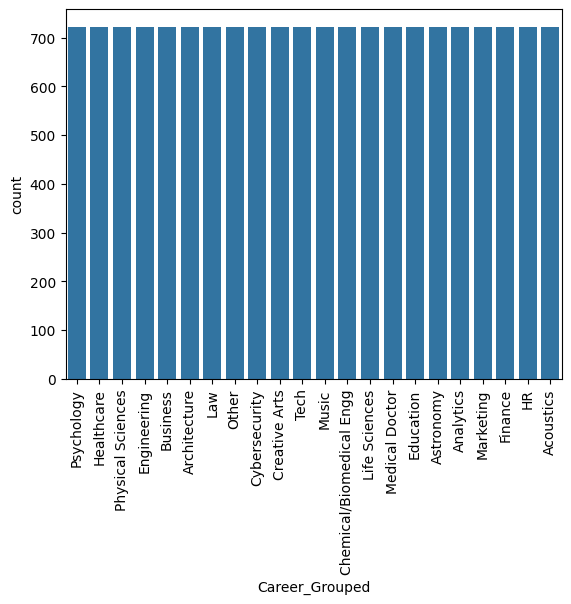

In [35]:
chart = sns.countplot(x=y_train)
chart.set_xticks(chart.get_xticks()) # Fixed tick positions
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.show()

In [36]:
X_train.shape,X_test.shape

((15884, 29), (1800, 29))

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

                           


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=400,random_state=42,
                                            max_depth=None,criterion='gini',
                                            min_samples_split=2,min_samples_leaf=1,
                                            max_features='sqrt',
                                            n_jobs=-1,
                                            class_weight='balanced',
                                            ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=2),
    #"SVM": SVC(kernel='linear',
              # degree=2,
              # gamma='scale')
    
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test,y_pred))
    probs = model.predict_proba(X_test)

    print("Top-1:", top_k_accuracy_score(y_test,probs, k=1))
    print("Top-3:", top_k_accuracy_score(y_test,probs, k=3))
    print("Top-5:", top_k_accuracy_score(y_test,probs, k=5))
    print("Top-10:", top_k_accuracy_score(y_test,probs, k=10))

    print("Training Accuracy Score: ",accuracy_score(model.predict(X_train),y_train))
    print("Testing Accuracy Score: ",accuracy_score(model.predict(X_test),y_test))
   

Logistic Regression Accuracy: 0.06
[[ 0  0  0  0  0  1  3  0  0  0  0  0  3  0  2  0  0  0  1  3  2  1]
 [ 0  0  3  0  2  1  1  0  5  1  3  1  6  0  1  1  2  2  0 11 10  3]
 [ 0  2  3  1  3  0  4  0  4  3  3  0  7  1  0  1  0  3  1 10 19  5]
 [ 0  0  1  0  0  0  1  0  3  0  0  0  1  1  2  1  1  0  1  5  7  1]
 [ 1  1  6  4 11  0  8  0 13  5  4  3 11  5  5  1  3  3  8 27 25  5]
 [ 0  0  1  1  4  0  4  0  0  2  0  0  1  2  2  1  0  1  1  8  6  3]
 [ 2  0  2  0 14  1  3  1  5  0  5  0 11  6  2  0  4  2  2 22  9  8]
 [ 1  0  1  0  1  0  0  0  1  1  0  1  1  0  1  1  0  0  0  4  2  2]
 [ 3  0  2  2 11  1  8  1  6  3  7  0  8  7  2  1  0  1  5 26 18  7]
 [ 5  1  3  1 12  2  7  0  3  4  1  1  4  3  4  3  4  4  3  6 16  6]
 [ 0  0  4  0 14  4  2  0  4  1  4  0  7  1  2  2  4  2  5 10 12  3]
 [ 0  0  1  1  0  1  0  0  0  0  0  0  0  2  0  2  0  1  0 10  3  2]
 [ 0  0  0  1 12  0  8  1  1  5  2  2  3  2  2  1  0  2  4 14 15  4]
 [ 2  1  0  4  5  0  4  0  9  6  6  1 12  4  8  2  1  2  5 28 19  7]

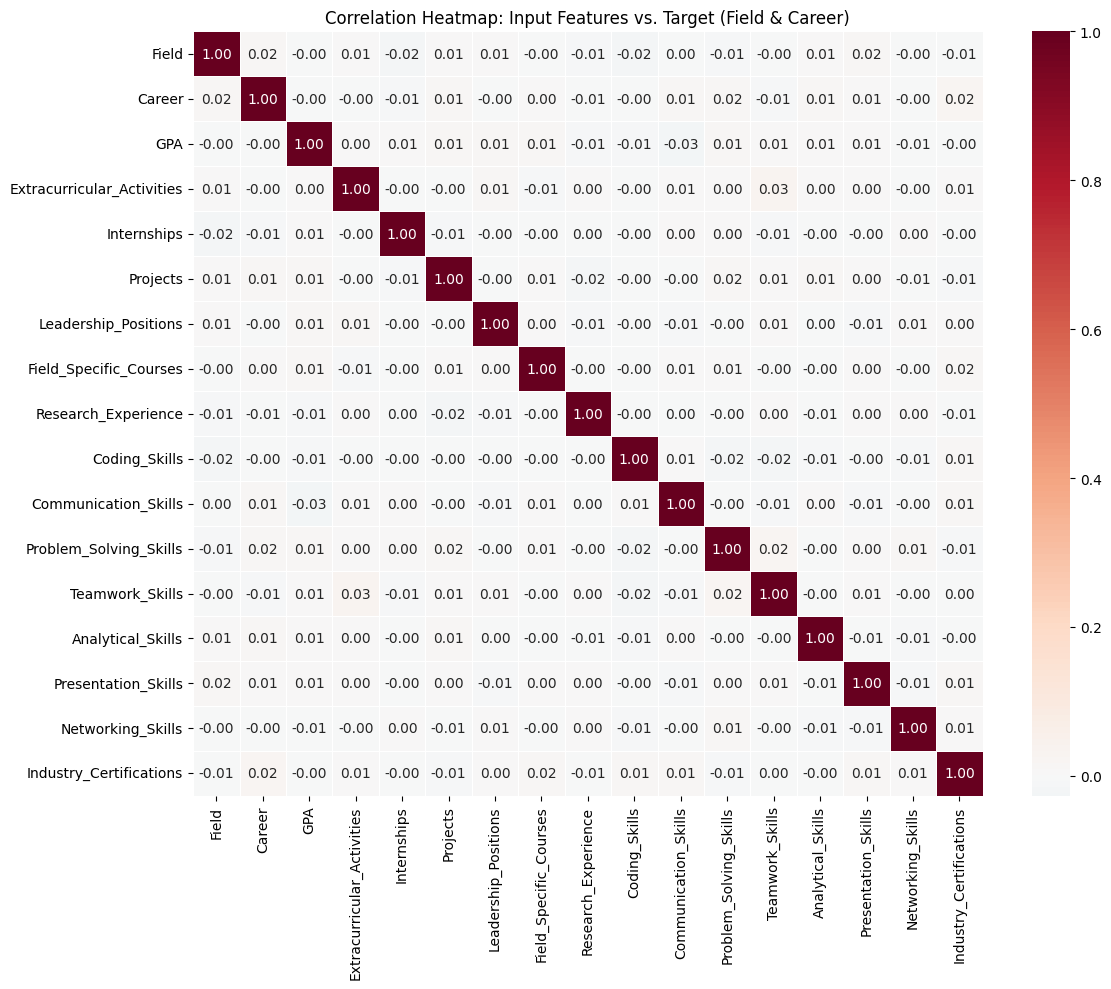

In [39]:
from sklearn.preprocessing import LabelEncoder


# 2. Encode Categorical features (Field and Career)
# We must convert text to numbers to calculate correlation
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['Field'] = le.fit_transform(df['Field'])
df_encoded['Career'] = le.fit_transform(df['Career'])

# 3. Calculate the Pearson Correlation Matrix
corr_matrix = df_encoded.corr()

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Input Features vs. Target (Field & Career)')
plt.tight_layout()
plt.show()

C:\Users\91810\AppData\Local\Temp\ipykernel_5724\3878997964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Field', data=df, order=df['Field'].value_counts().index, palette='viridis')


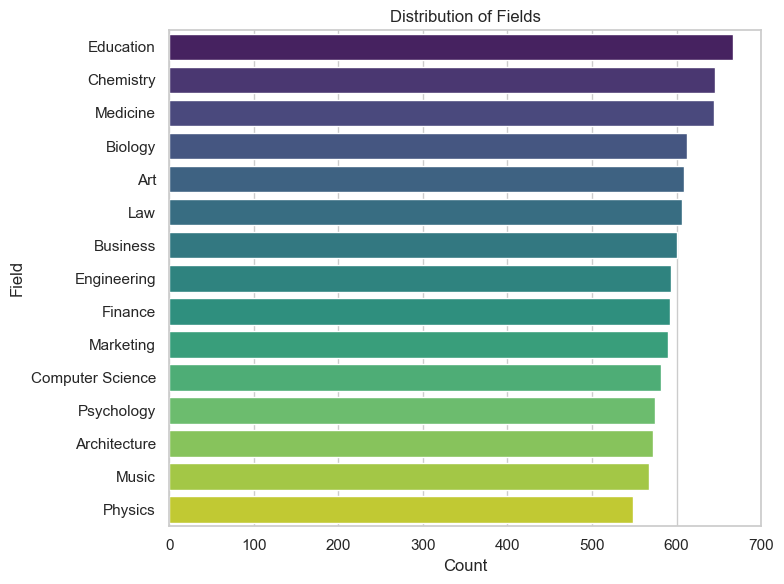

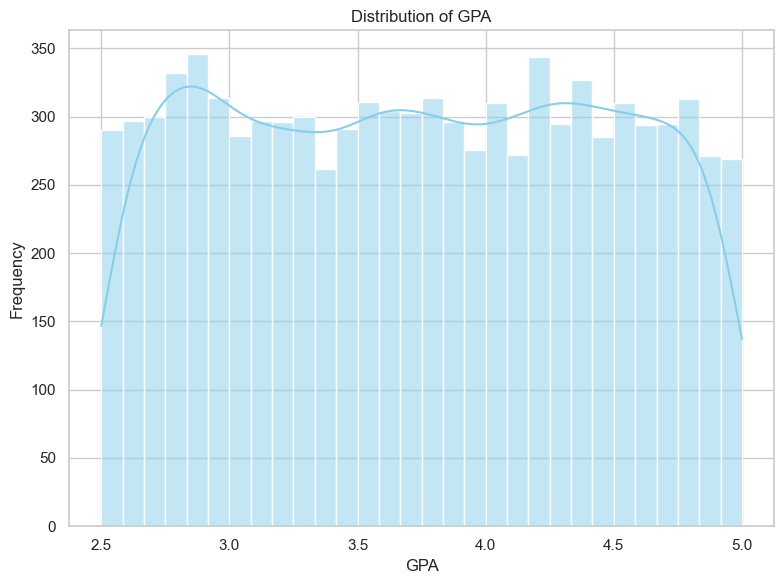

In [40]:
# Set the visual style for the plots
sns.set(style="whitegrid")

# --- 1. Distribution of Fields ---
plt.figure(figsize=(8, 6))
sns.countplot(y='Field', data=df, order=df['Field'].value_counts().index, palette='viridis')
plt.title('Distribution of Fields')
plt.xlabel('Count')
plt.ylabel('Field')
plt.tight_layout()
plt.show() # Use plt.savefig('field_distribution.png') to save

# --- 2. GPA Distribution ---
plt.figure(figsize=(8, 6))
sns.histplot(df['GPA'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

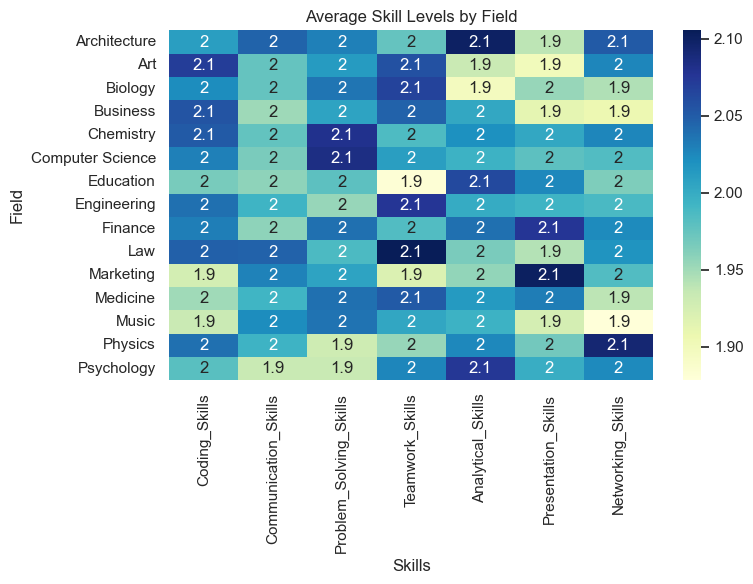

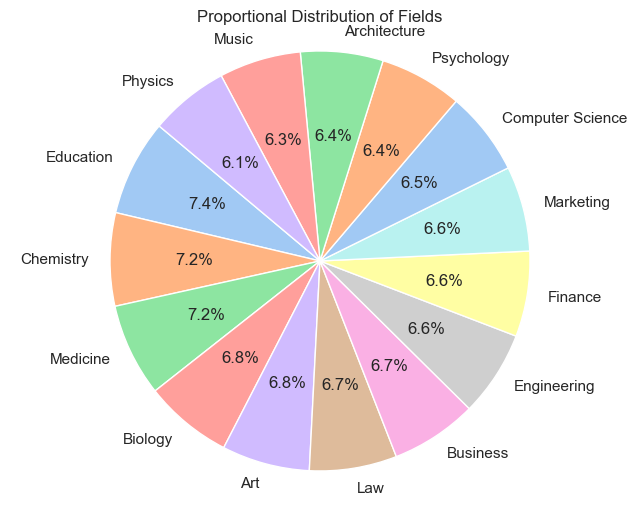

C:\Users\91810\AppData\Local\Temp\ipykernel_5724\279071536.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Internships', data=df, ax=axes[0, 0], palette='Blues')
C:\Users\91810\AppData\Local\Temp\ipykernel_5724\279071536.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Leadership_Positions', data=df, ax=axes[0, 1], palette='Greens')
C:\Users\91810\AppData\Local\Temp\ipykernel_5724\279071536.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Research_Experience', data=df, ax=axes[1, 0], palette='Oranges')
C:\Users\91

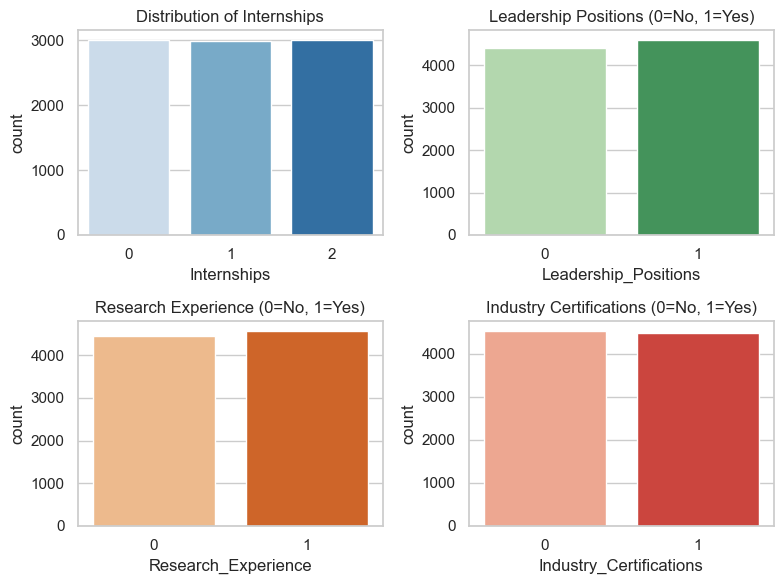

In [41]:
# --- 5. Average Skill Levels by Field ---
# List of skill-related columns to aggregate
skill_cols = [
    'Coding_Skills', 'Communication_Skills', 'Problem_Solving_Skills', 
    'Teamwork_Skills', 'Analytical_Skills', 'Presentation_Skills', 'Networking_Skills'
]
avg_skills = df.groupby('Field')[skill_cols].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(avg_skills, annot=True, cmap='YlGnBu')
plt.title('Average Skill Levels by Field')
plt.xlabel('Skills')
plt.ylabel('Field')
plt.tight_layout()
plt.show()

# --- 6. Pie Chart for Fields ---
plt.figure(figsize=(8, 6))
field_counts = df['Field'].value_counts()
plt.pie(field_counts, labels=field_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportional Distribution of Fields')
plt.axis('equal')
plt.show()

# --- 7. Distribution of Discrete/Binary Features (Subplots) ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.countplot(x='Internships', data=df, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Distribution of Internships')

sns.countplot(x='Leadership_Positions', data=df, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('Leadership Positions (0=No, 1=Yes)')

sns.countplot(x='Research_Experience', data=df, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('Research Experience (0=No, 1=Yes)')

sns.countplot(x='Industry_Certifications', data=df, ax=axes[1, 1], palette='Reds')
axes[1, 1].set_title('Industry Certifications (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

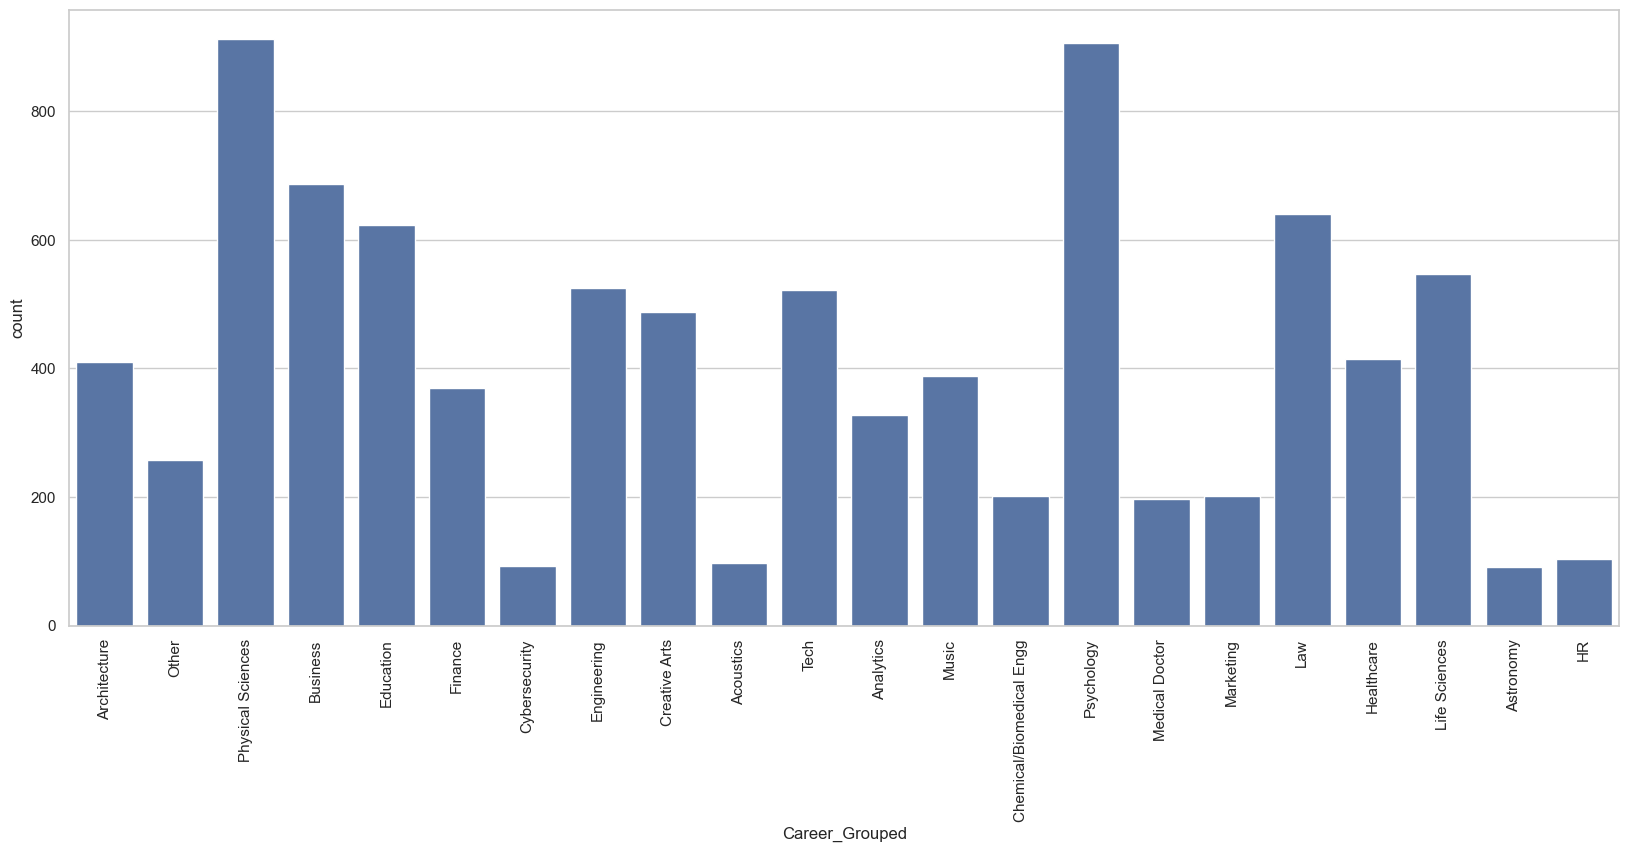

In [42]:
plt.figure(figsize=(20,8))
chart = sns.countplot(x=data['Career_Grouped'])
chart.set_xticks(chart.get_xticks()) # Fixed tick positions
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.show()

In [43]:
plt.figure(figsize=(20,8))

<Figure size 2000x800 with 0 Axes>

<Figure size 2000x800 with 0 Axes>

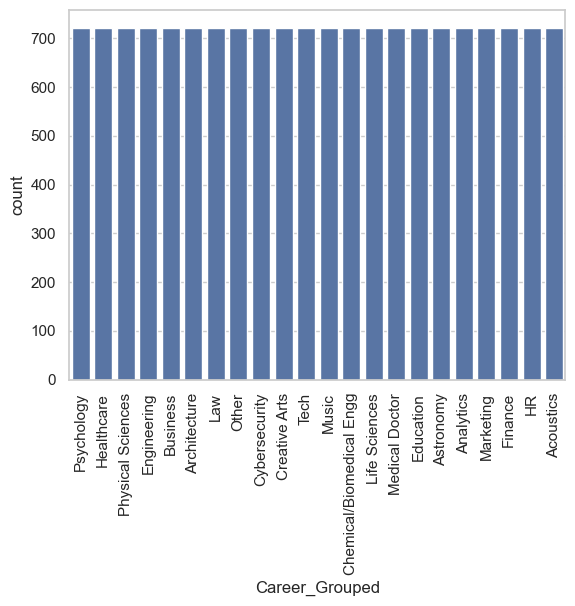

In [44]:
chart = sns.countplot(x=y_train)
chart.set_xticks(chart.get_xticks()) # Fixed tick positions
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.show()

In [45]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

In [46]:
'''import pickle
import sklearn

print(f"Current sklearn version: {sklearn.__version__}")

# Re-saving the artifacts with your current version (1.8.0)
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("Files re-saved successfully!")'''

'import pickle\nimport sklearn\n\nprint(f"Current sklearn version: {sklearn.__version__}")\n\n# Re-saving the artifacts with your current version (1.8.0)\npickle.dump(model, open("model.pkl", "wb"))\npickle.dump(scaler, open("scaler.pkl", "wb"))\npickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))\n\nprint("Files re-saved successfully!")'

In [47]:
'''import pickle

# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save columns
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))'''

'import pickle\n\n# Save model\npickle.dump(model, open("model.pkl", "wb"))\n\n# Save scaler\npickle.dump(scaler, open("scaler.pkl", "wb"))\n\n# Save columns\npickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))'

In [48]:
'''from flask import Flask, render_template, request, url_for
import pickle
import numpy as np
import os

# Flask automatically 'templates' aur 'static' folder
app = Flask(__name__)

# 1. Model aur Scaler load 
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/home')
def home():
    return render_template('home.html')

@app.route('/about')
def about():
    return render_template('about.html')

@app.route('/process')
def process():
    return render_template('process.html')

@app.route('/contact')
def contact():
    return render_template('contact.html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        
        features = [float(x) for x in request.form.values() if x.replace('.','',1).isdigit()]
        
        # Scaling and Prediction
        final_features = scaler.transform([features])
        prediction = model.predict(final_features)
        
        return f"<h1>Your Predicted Career Path: {prediction[0]}</h1><br><a href='/home'>Try Again</a>"
    except Exception as e:
        return f"Error: {str(e)}"

if __name__ == '__main__':
    app.run(port=5000)'''

'from flask import Flask, render_template, request, url_for\nimport pickle\nimport numpy as np\nimport os\n\n# Flask automatically \'templates\' aur \'static\' folder\napp = Flask(__name__)\n\n# 1. Model aur Scaler load \nmodel = pickle.load(open("model.pkl", "rb"))\nscaler = pickle.load(open("scaler.pkl", "rb"))\n\n@app.route(\'/\')\ndef index():\n    return render_template(\'index.html\')\n\n@app.route(\'/home\')\ndef home():\n    return render_template(\'home.html\')\n\n@app.route(\'/about\')\ndef about():\n    return render_template(\'about.html\')\n\n@app.route(\'/process\')\ndef process():\n    return render_template(\'process.html\')\n\n@app.route(\'/contact\')\ndef contact():\n    return render_template(\'contact.html\')\n\n@app.route(\'/predict\', methods=[\'POST\'])\ndef predict():\n    try:\n\n        features = [float(x) for x in request.form.values() if x.replace(\'.\',\'\',1).isdigit()]\n\n        # Scaling and Prediction\n        final_features = scaler.transform([featur